<a href="https://colab.research.google.com/github/Amira509-7/GlassHeart_Research_AI/blob/main/the_msgic_data_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
cols=["fLenght","fWidth","fSize","fConc","fConcl","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"]
df = pd.read_csv('magic04.data',names = cols)
df.head()


,fLenght,fWidth,fSize,fConc,fConcl,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df["class"]=(df["class"]== "g").astype(int)

In [4]:
df.head()

,fLenght,fWidth,fSize,fConc,fConcl,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


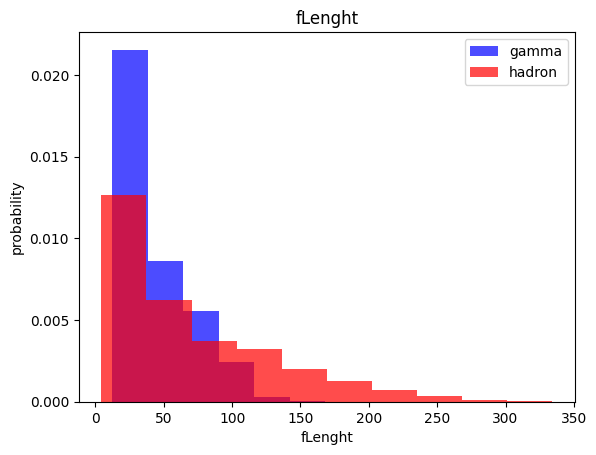

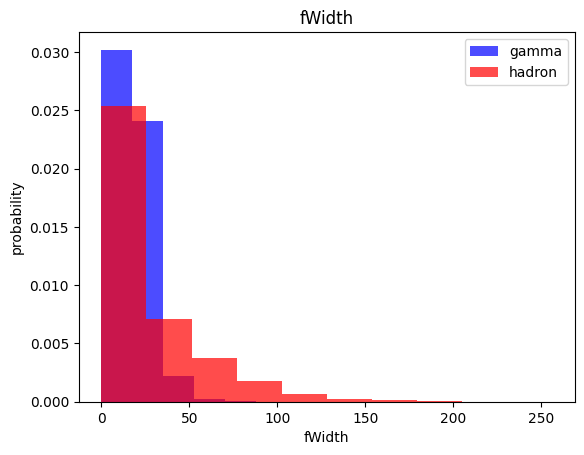

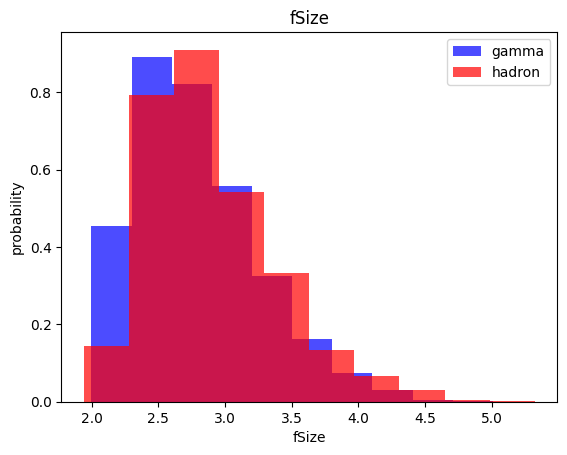

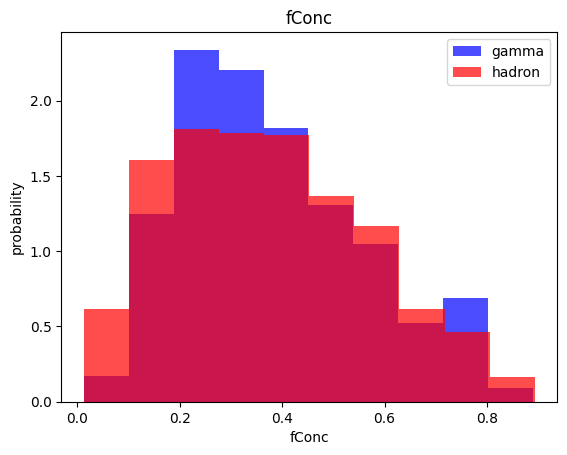

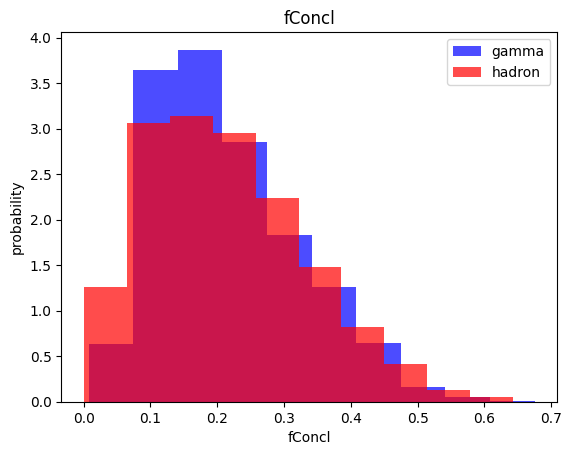

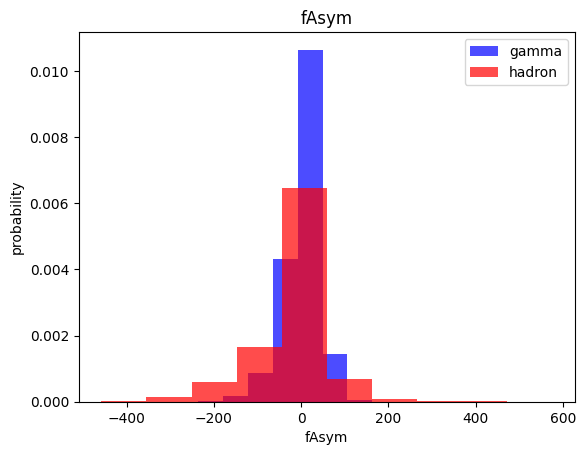

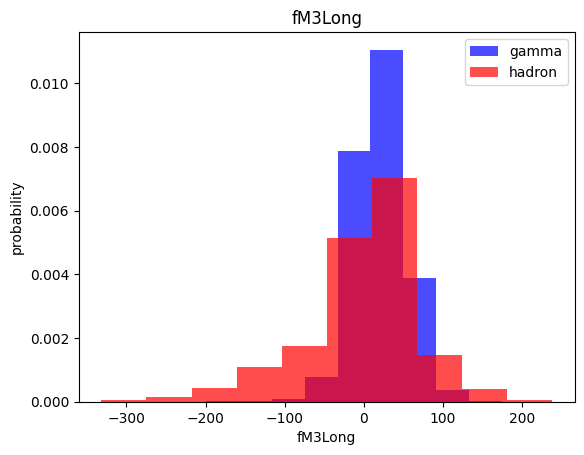

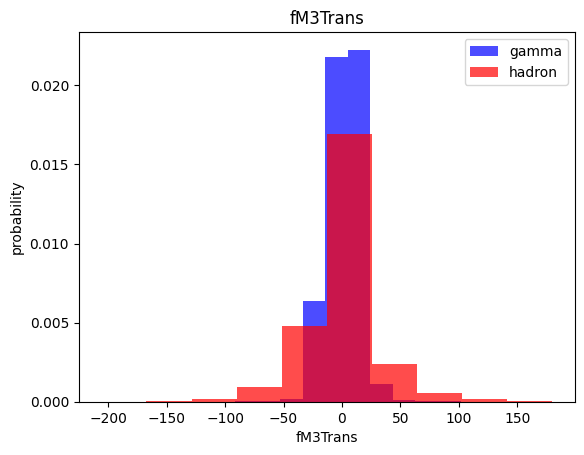

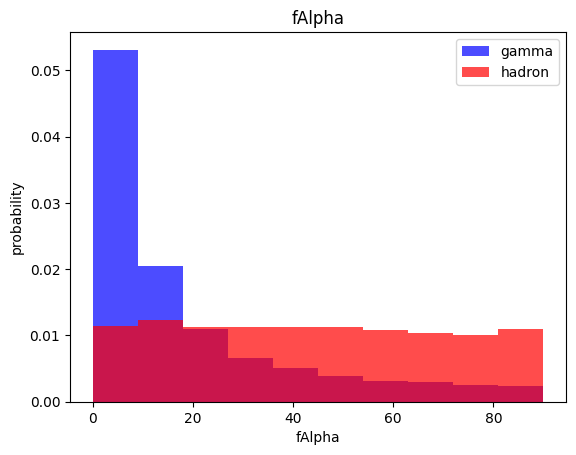

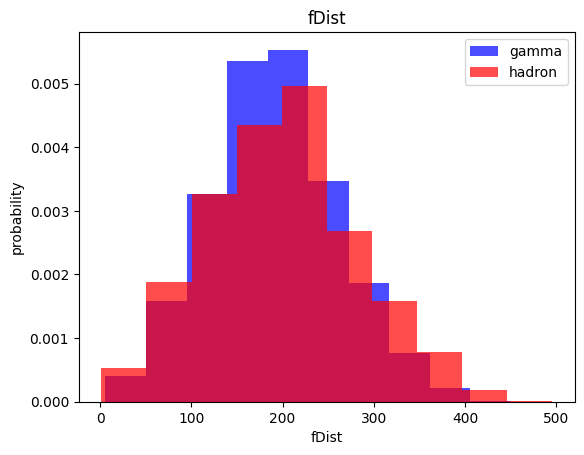

In [5]:
for label in cols [:-1]:
  plt.hist(df[df["class"]==1][label],color='blue',label='gamma',alpha=.7,density=True)
  plt.hist(df[df["class"]==0][label],color='red',label='hadron',alpha=0.7,density=True)
  plt.title(label)
  plt.ylabel("probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

In [6]:
train, vaild, test = np.split(df.sample(frac=1),[int(0.6*len(df)),int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [7]:
def scale_dataset (dataframe,oversample=False ):
  X=dataframe[dataframe.columns[:-1]].values
  Y=dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  if oversample:
    ros= RandomOverSampler()
    X,Y = ros.fit_resample(X,Y)


  data = np.hstack((X, np.reshape(Y,(-1,1))))

  return data,X,Y




In [8]:
train, X_train, Y_train = scale_dataset(train, oversample= True)
vaild , X_vaild, Y_vaild = scale_dataset(vaild, oversample = False)
test, X_test, Y_test = scale_dataset(test, oversample = False)

## **KNN**

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [10]:
Knn_model = KNeighborsClassifier(n_neighbors=3)
Knn_model.fit(X_train, Y_train)


KNeighborsClassifier(n_neighbors=3)

In [11]:
Y_pred = Knn_model.predict(X_test)

In [12]:
print(classification_report( Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.73      0.73      0.73      1338
           1       0.85      0.86      0.85      2466

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



# Naive Bayes

In [13]:
from sklearn.naive_bayes import GaussianNB

In [14]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, Y_train)

In [15]:
Y_pred = nb_model.predict(X_test)
print(classification_report( Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.66      0.38      0.48      1338
           1       0.73      0.89      0.80      2466

    accuracy                           0.71      3804
   macro avg       0.69      0.64      0.64      3804
weighted avg       0.70      0.71      0.69      3804



# Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train,Y_train)

In [18]:
Y_pred = lg_model.predict(X_test)
print(classification_report( Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.69      0.72      0.70      1338
           1       0.84      0.82      0.83      2466

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.77      3804
weighted avg       0.79      0.78      0.79      3804



# SVM

In [19]:
from sklearn.svm import SVC

In [20]:
svm_model = SVC()
svm_model = svm_model.fit(X_train,Y_train)

In [21]:
Y_pred = svm_model.predict(X_test)
print(classification_report( Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1338
           1       0.90      0.89      0.89      2466

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



## Nerual network

In [22]:
import tensorflow as tf



In [23]:


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary crossentropy')
    ax1.grid(True)


    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)

    plt.show()

In [24]:
def train_model(X_train, Y_train, num_nodes, dropout_prob, lr, batch_size, epochs):

    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = nn_model.fit(
        X_train,
        Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    return nn_model, history

16nodes, dropout 0,lr0.01,batch_size32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


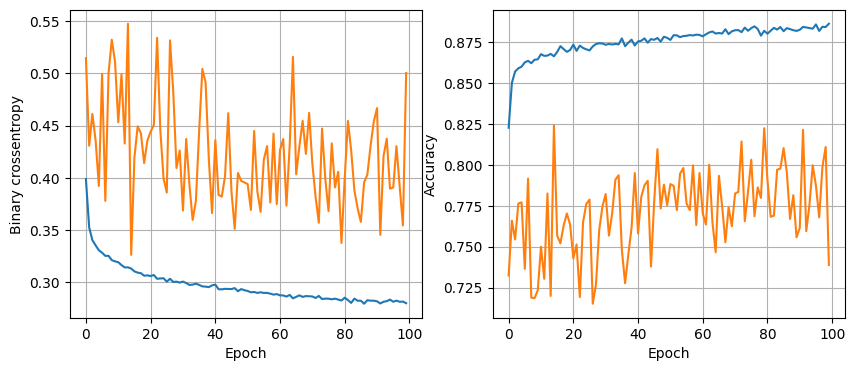

16nodes, dropout 0,lr0.01,batch_size64


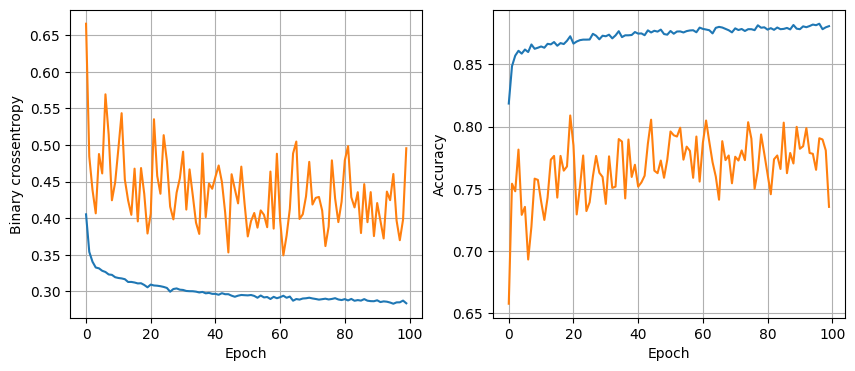

16nodes, dropout 0,lr0.01,batch_size128


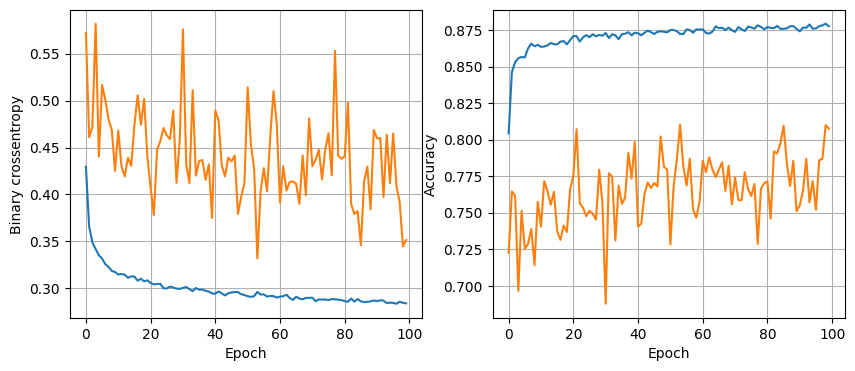

16nodes, dropout 0,lr0.005,batch_size32


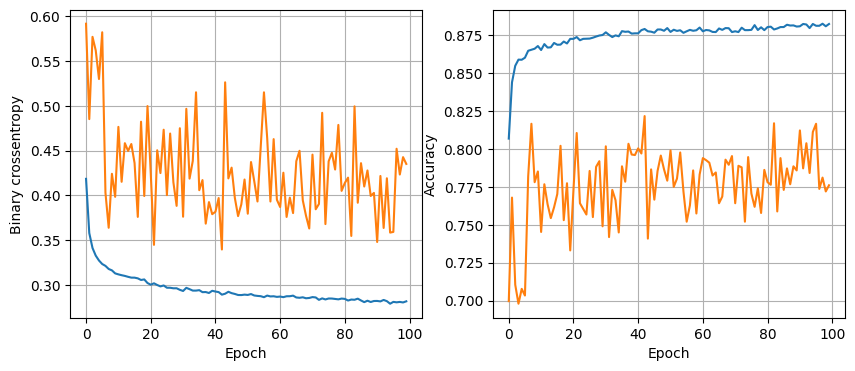

16nodes, dropout 0,lr0.005,batch_size64


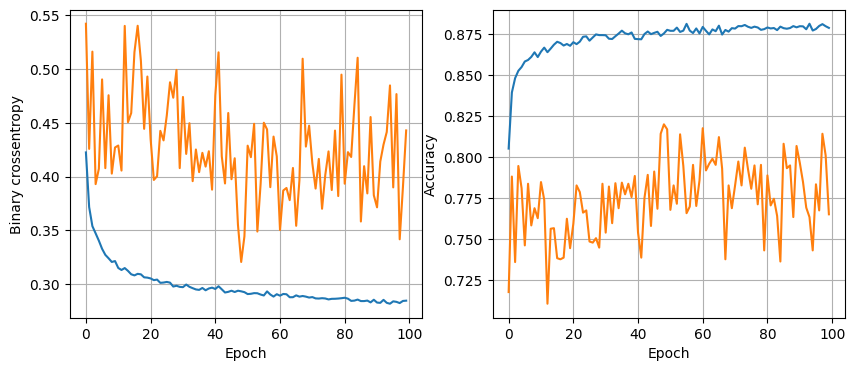

16nodes, dropout 0,lr0.005,batch_size128


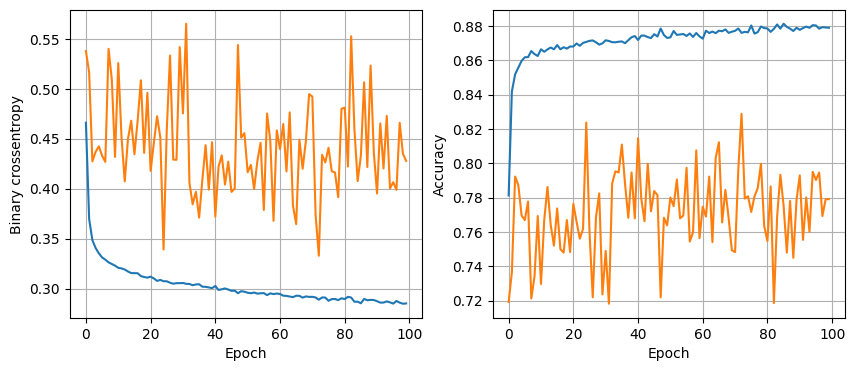

16nodes, dropout 0,lr0.001,batch_size32


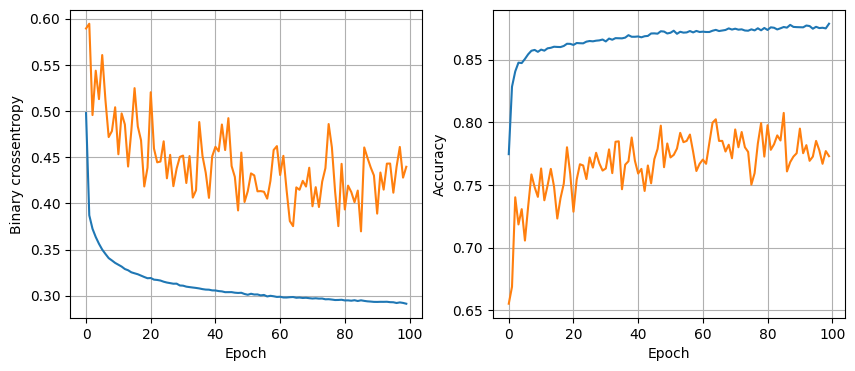

16nodes, dropout 0,lr0.001,batch_size64


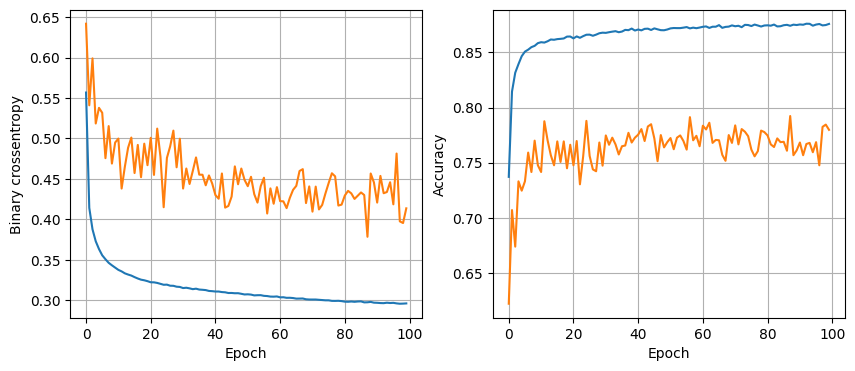

16nodes, dropout 0,lr0.001,batch_size128


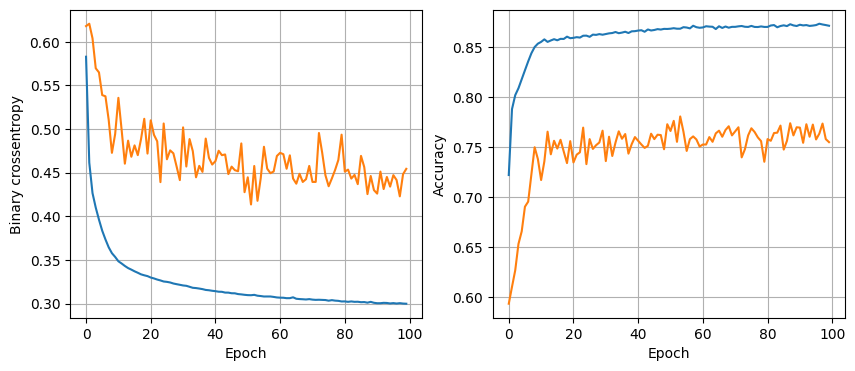

16nodes, dropout 0.2,lr0.01,batch_size32


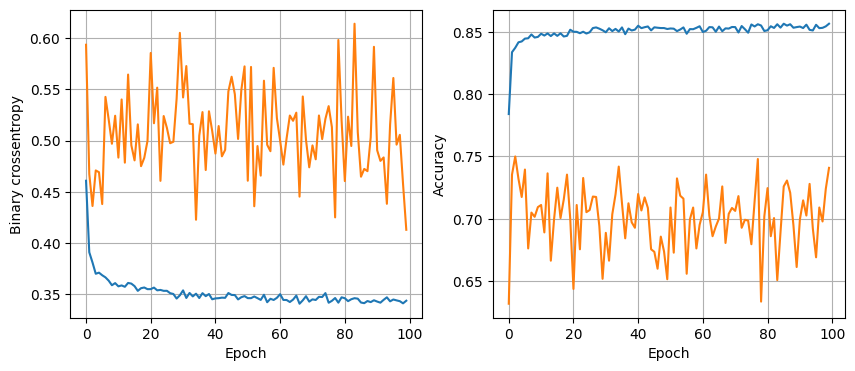

16nodes, dropout 0.2,lr0.01,batch_size64


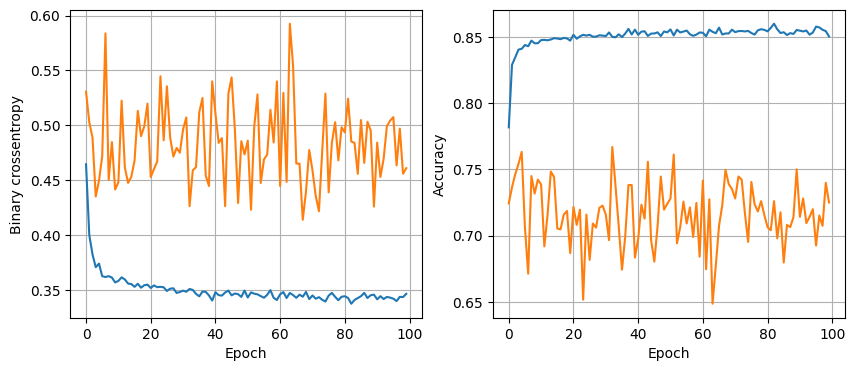

16nodes, dropout 0.2,lr0.01,batch_size128


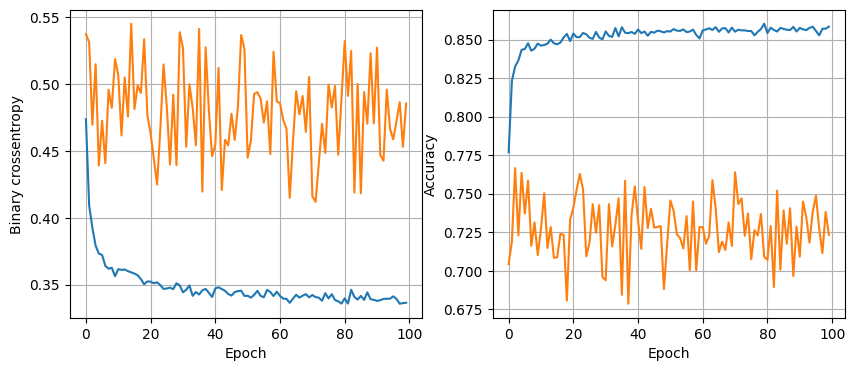

16nodes, dropout 0.2,lr0.005,batch_size32


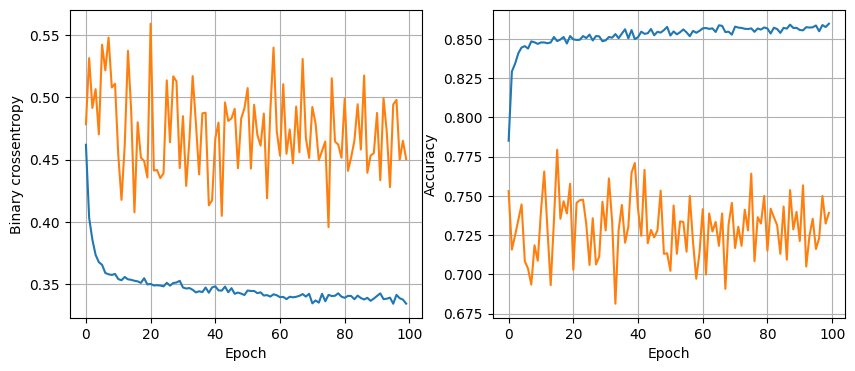

16nodes, dropout 0.2,lr0.005,batch_size64


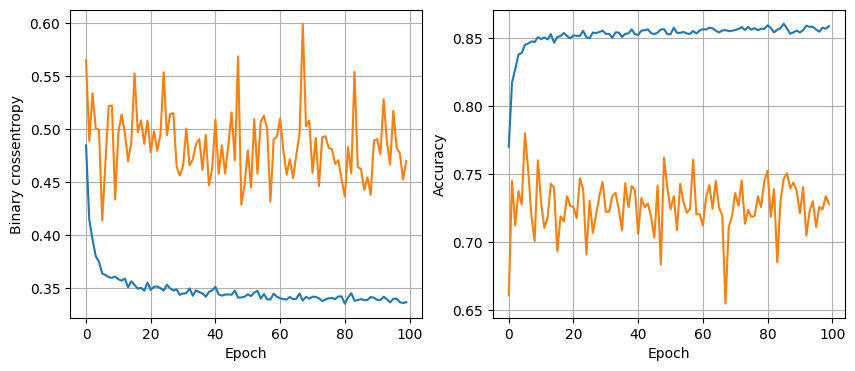

16nodes, dropout 0.2,lr0.005,batch_size128


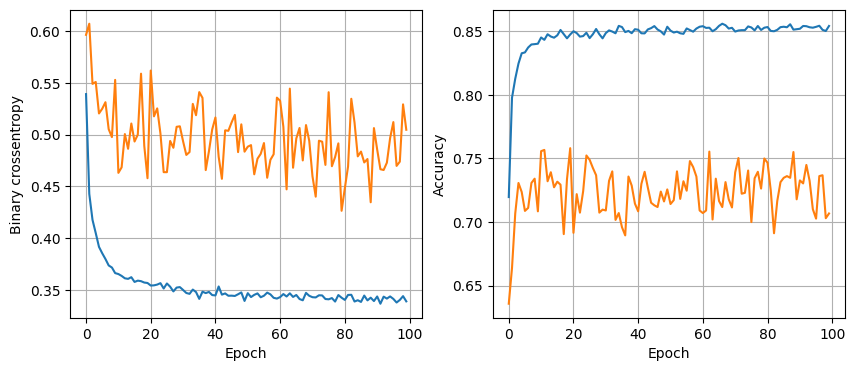

16nodes, dropout 0.2,lr0.001,batch_size32


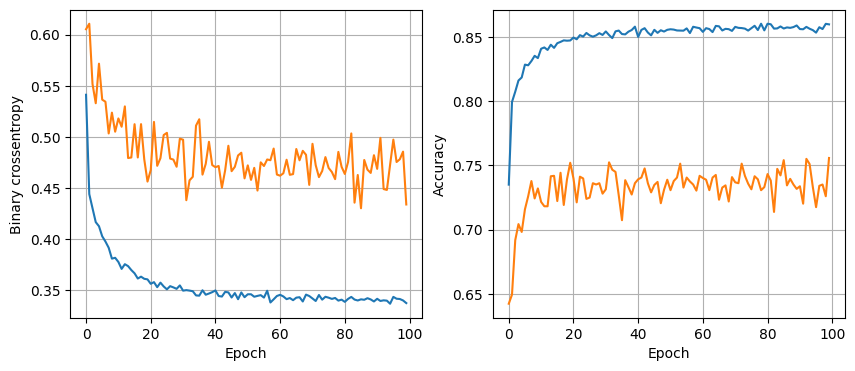

16nodes, dropout 0.2,lr0.001,batch_size64


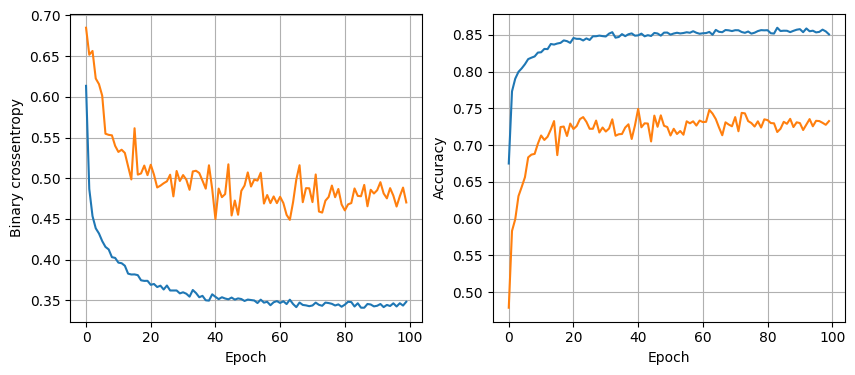

16nodes, dropout 0.2,lr0.001,batch_size128


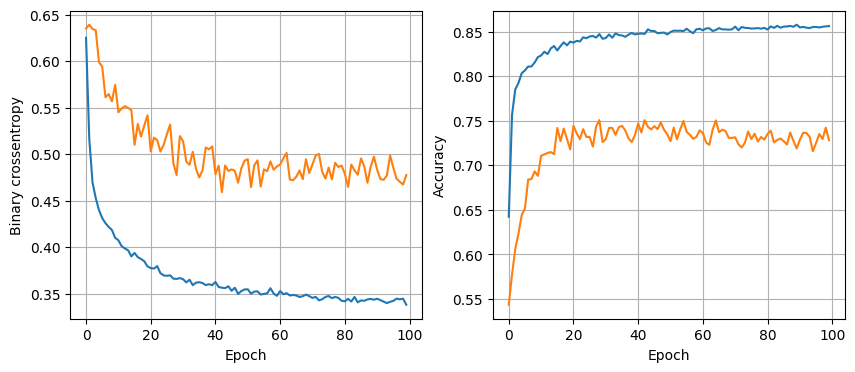

23nodes, dropout 0,lr0.01,batch_size32


In [ ]:
least_val_loss = float('inf')
least_loss_epoch = None
epochs=100
for num_nodes in [16,23,64]:
  for dropout_prob in [0,0.2]:
   for lr in [0.01,0.005,0.001]:
    for batch_size in [32,64,128]:
      print(f"{num_nodes}nodes, dropout {dropout_prob},lr{lr},batch_size{batch_size}")
      model,history = train_model(X_train,Y_train,num_nodes,dropout_prob,lr,batch_size,epochs)
      plot_history(history)
    val_loss = min(history.history['val_loss'])
val_accuracy = max(history.history['val_accuracy'])

if val_loss < least_val_loss:
    least_val_loss = val_loss
    least_loss_model = model



In [ ]:
plot_loss(history)
plot_accuracy(history)

In [ ]:
y_pred=least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)

In [ ]:
print(classification_report( Y_test, Y_pred))